In [3]:
!pip install kagglehub

In [4]:
import os
import time
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.optim import lr_scheduler
from torch.utils.data import DataLoader


from PIL import Image

import kagglehub
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet101, ResNet101_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


In [5]:
dataset_path = kagglehub.dataset_download(
    "aryashah2k/breast-ultrasound-images-dataset"
)

print("Dataset downloaded at:", dataset_path)

Using Colab cache for faster access to the 'breast-ultrasound-images-dataset' dataset.
Dataset downloaded at: /kaggle/input/breast-ultrasound-images-dataset


In [6]:
dataset_folder = os.path.join(dataset_path, "Dataset_BUSI_with_GT")

class_labels = ["benign", "malignant", "normal"]

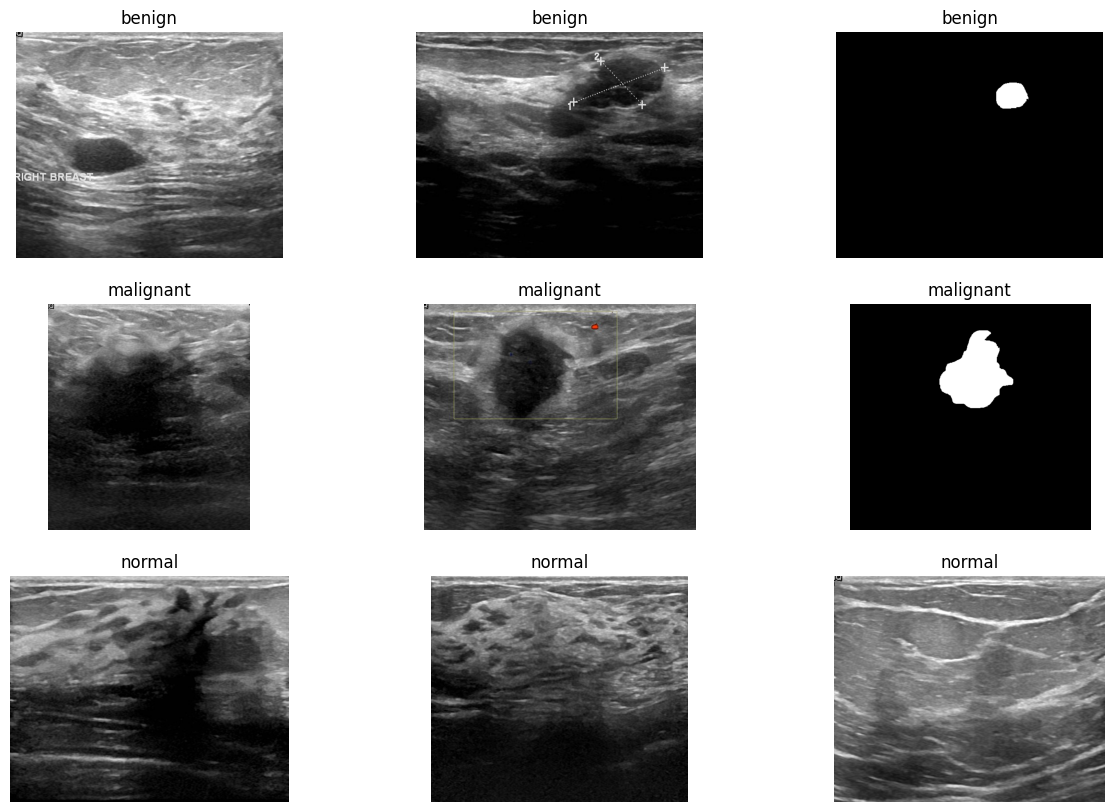

In [7]:
fig, axes = plt.subplots(3,3,figsize=(15,10))

for i, category in enumerate(class_labels):

    folder = os.path.join(dataset_folder, category)

    images = [f for f in os.listdir(folder) if f.endswith(".png")]

    for j in range(3):

        img_path = os.path.join(folder, images[j])

        img = Image.open(img_path)

        axes[i,j].imshow(img, cmap="gray")
        axes[i,j].set_title(category)
        axes[i,j].axis("off")

plt.show()

In [28]:
import os

train_folder = os.path.join(workspace_dir, "train")

print("Training Dataset Distribution\n")

for cls in class_labels:

    path = os.path.join(train_folder, cls)

    count = len(os.listdir(path))

    print(cls, ":", count)
    val_folder = os.path.join(workspace_dir, "val")

print("\nValidation Dataset Distribution\n")

for cls in class_labels:

    path = os.path.join(val_folder, cls)

    count = len(os.listdir(path))

    print(cls, ":", count)
    test_folder = os.path.join(workspace_dir, "test")

print("\nTest Dataset Distribution\n")

for cls in class_labels:

    path = os.path.join(test_folder, cls)

    count = len(os.listdir(path))

    print(cls, ":", count)
    import pandas as pd

data_summary = []

for dataset_type, folder in zip(
    ["Train","Validation","Test"],
    [train_folder,val_folder,test_folder]
):

    for cls in class_labels:

        count = len(os.listdir(os.path.join(folder,cls)))

        data_summary.append([dataset_type,cls,count])

summary_df = pd.DataFrame(
    data_summary,
    columns=["Dataset","Class","Image Count"]
)

print(summary_df)

Training Dataset Distribution

benign : 306
malignant : 147
normal : 93

Validation Dataset Distribution

benign : 65
malignant : 32
normal : 20

Test Dataset Distribution

benign : 66
malignant : 31
normal : 20
      Dataset      Class  Image Count
0       Train     benign          306
1       Train  malignant          147
2       Train     normal           93
3  Validation     benign           65
4  Validation  malignant           32
5  Validation     normal           20
6        Test     benign           66
7        Test  malignant           31
8        Test     normal           20


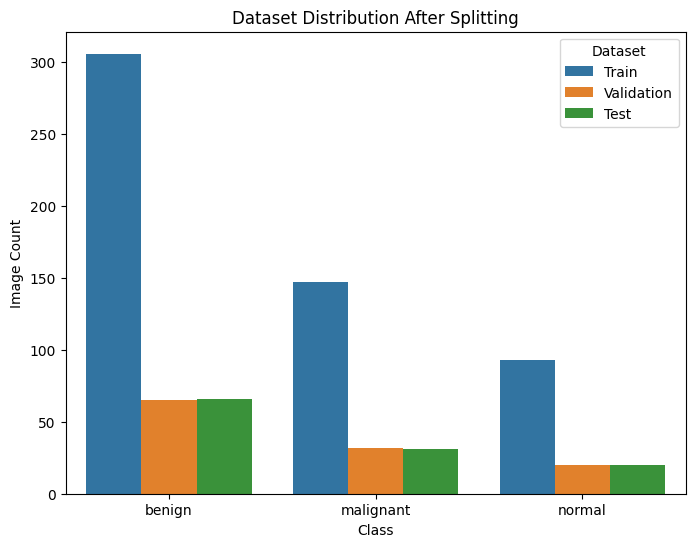

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.barplot(
    data=summary_df,
    x="Class",
    y="Image Count",
    hue="Dataset"
)

plt.title("Dataset Distribution After Splitting")

plt.show()

In [8]:
workspace_dir = "/content/project_workspace"

os.makedirs(workspace_dir, exist_ok=True)

print("Workspace created")

Workspace created


In [9]:
train_transform = transforms.Compose([
    transforms.Resize(260),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize(260),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])

In [10]:
image_paths = []
image_labels = []

for category in os.listdir(dataset_folder):

    category_path = os.path.join(dataset_folder, category)

    if os.path.isdir(category_path):

        for img in os.listdir(category_path):

            if img.endswith(".png") and "_mask" not in img:

                image_paths.append(
                    os.path.join(category_path,img)
                )

                image_labels.append(category)

dataset_df = pd.DataFrame({
    "path": image_paths,
    "label": image_labels
})

dataset_df.head()

,path,label
0,/kaggle/input/breast-ultrasound-images-dataset...,benign
1,/kaggle/input/breast-ultrasound-images-dataset...,benign
2,/kaggle/input/breast-ultrasound-images-dataset...,benign
3,/kaggle/input/breast-ultrasound-images-dataset...,benign
4,/kaggle/input/breast-ultrasound-images-dataset...,benign


In [11]:
train_df, temp_df = train_test_split(
    dataset_df,
    test_size=0.3,
    stratify=dataset_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

In [12]:
train_folder = os.path.join(workspace_dir,"train")
val_folder = os.path.join(workspace_dir,"val")
test_folder = os.path.join(workspace_dir,"test")

for folder in [train_folder,val_folder,test_folder]:

    for c in class_labels:

        os.makedirs(os.path.join(folder,c),exist_ok=True)

In [13]:
def copy_images(dataframe, destination):

    for _, row in dataframe.iterrows():

        src = row["path"]
        label = row["label"]

        dst = os.path.join(destination,label,os.path.basename(src))

        shutil.copy(src,dst)


copy_images(train_df,train_folder)
copy_images(val_df,val_folder)
copy_images(test_df,test_folder)

In [14]:
data_root = workspace_dir

datasets_dict = {
    "train": ImageFolder(train_folder, transform=train_transform),
    "val": ImageFolder(val_folder, transform=test_transform),
    "test": ImageFolder(test_folder, transform=test_transform)
}

In [15]:
batch_size = 10

data_loaders = {

    x: DataLoader(
        datasets_dict[x],
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )

    for x in ["train","val","test"]
}

dataset_sizes = {x: len(datasets_dict[x]) for x in datasets_dict}

class_names = datasets_dict["train"].classes

print(class_names)

['benign', 'malignant', 'normal']


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:",device)

Device: cuda


In [17]:
model = resnet101(weights=ResNet101_Weights.DEFAULT)

num_features = model.fc.in_features

model.fc = nn.Linear(num_features,len(class_names))

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:00<00:00, 195MB/s]


In [18]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(),lr=0.00004)

scheduler = lr_scheduler.StepLR(
    optimizer,
    step_size=6,
    gamma=0.15
)

In [19]:
def train_model(model,epochs=15):

    for epoch in range(epochs):

        print("Epoch",epoch+1)

        model.train()

        running_loss = 0

        for inputs,labels in data_loaders["train"]:

            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs,labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        scheduler.step()

        print("Loss:",running_loss)

    return model


trained_model = train_model(model)

Epoch 1
Loss: 54.56143206357956
Epoch 2
Loss: 45.80203902721405
Epoch 3
Loss: 38.132293075323105
Epoch 4
Loss: 30.43523782491684
Epoch 5
Loss: 26.032886877655983
Epoch 6
Loss: 22.181677915155888
Epoch 7
Loss: 20.66959658265114
Epoch 8
Loss: 19.957096122205257
Epoch 9
Loss: 19.169362172484398
Epoch 10
Loss: 16.77795834839344
Epoch 11
Loss: 18.732797384262085
Epoch 12
Loss: 17.283024862408638
Epoch 13
Loss: 16.103790409862995
Epoch 14
Loss: 17.713832046836615
Epoch 15
Loss: 15.793181877583265


In [20]:
model_path = os.path.join(
    workspace_dir,
    "resnet_breast_model.pth"
)

torch.save(trained_model,model_path)

print("Model saved at:",model_path)

Model saved at: /content/project_workspace/resnet_breast_model.pth


In [21]:
true_labels = []
pred_labels = []
prob_scores = []

trained_model.eval()

with torch.no_grad():

    for images,labels in data_loaders["test"]:

        images = images.to(device)

        outputs = trained_model(images)

        probs = torch.softmax(outputs,dim=1)

        _,preds = torch.max(outputs,1)

        true_labels.extend(labels.numpy())
        pred_labels.extend(preds.cpu().numpy())
        prob_scores.extend(probs.cpu().numpy())

In [22]:
acc = accuracy_score(true_labels,pred_labels)

prec = precision_score(true_labels,pred_labels,average="weighted")

rec = recall_score(true_labels,pred_labels,average="weighted")

f1 = f1_score(true_labels,pred_labels,average="weighted")

print("Accuracy:",acc)
print("Precision:",prec)
print("Recall:",rec)
print("F1 Score:",f1)

Accuracy: 0.7863247863247863
Precision: 0.7852959797404242
Recall: 0.7863247863247863
F1 Score: 0.7836796851236999


In [23]:
print(
    classification_report(
        true_labels,
        pred_labels,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      benign       0.79      0.86      0.83        66
   malignant       0.74      0.65      0.69        31
      normal       0.83      0.75      0.79        20

    accuracy                           0.79       117
   macro avg       0.79      0.75      0.77       117
weighted avg       0.79      0.79      0.78       117



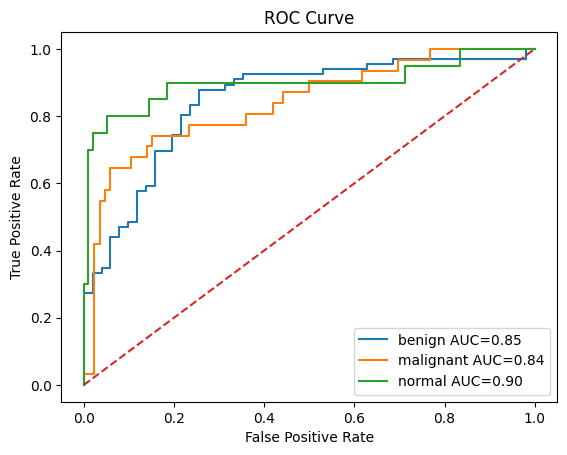

In [25]:
true_bin = label_binarize(true_labels,classes=[0,1,2])

prob_scores = np.array(prob_scores)

for i in range(3):

    fpr,tpr,_ = roc_curve(true_bin[:,i],prob_scores[:,i])

    roc_auc = auc(fpr,tpr)

    plt.plot(fpr,tpr,label=f"{class_names[i]} AUC={roc_auc:.2f}")

plt.plot([0,1],[0,1],"--")

plt.legend()

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.show()

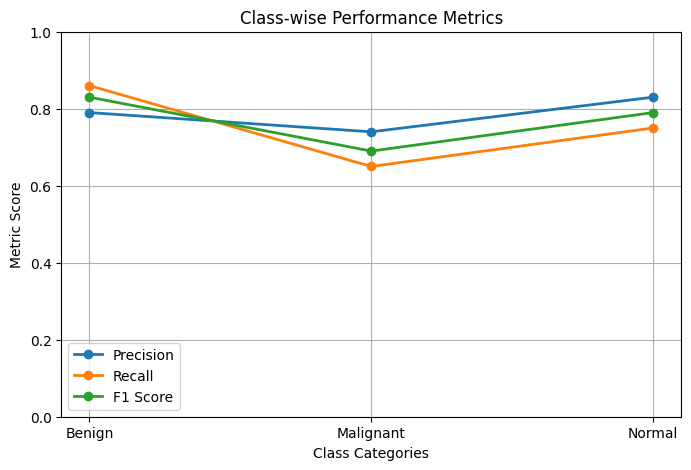

In [27]:
import matplotlib.pyplot as plt


classes = ["Benign", "Malignant", "Normal"]


precision = [0.79, 0.74, 0.83]
recall = [0.86, 0.65, 0.75]
f1_score = [0.83, 0.69, 0.79]

plt.figure(figsize=(8,5))

plt.plot(classes, precision, marker='o', linewidth=2, label="Precision")
plt.plot(classes, recall, marker='o', linewidth=2, label="Recall")
plt.plot(classes, f1_score, marker='o', linewidth=2, label="F1 Score")

plt.title("Class-wise Performance Metrics")
plt.xlabel("Class Categories")
plt.ylabel("Metric Score")

plt.ylim(0,1)

plt.legend()

plt.grid(True)

plt.show()

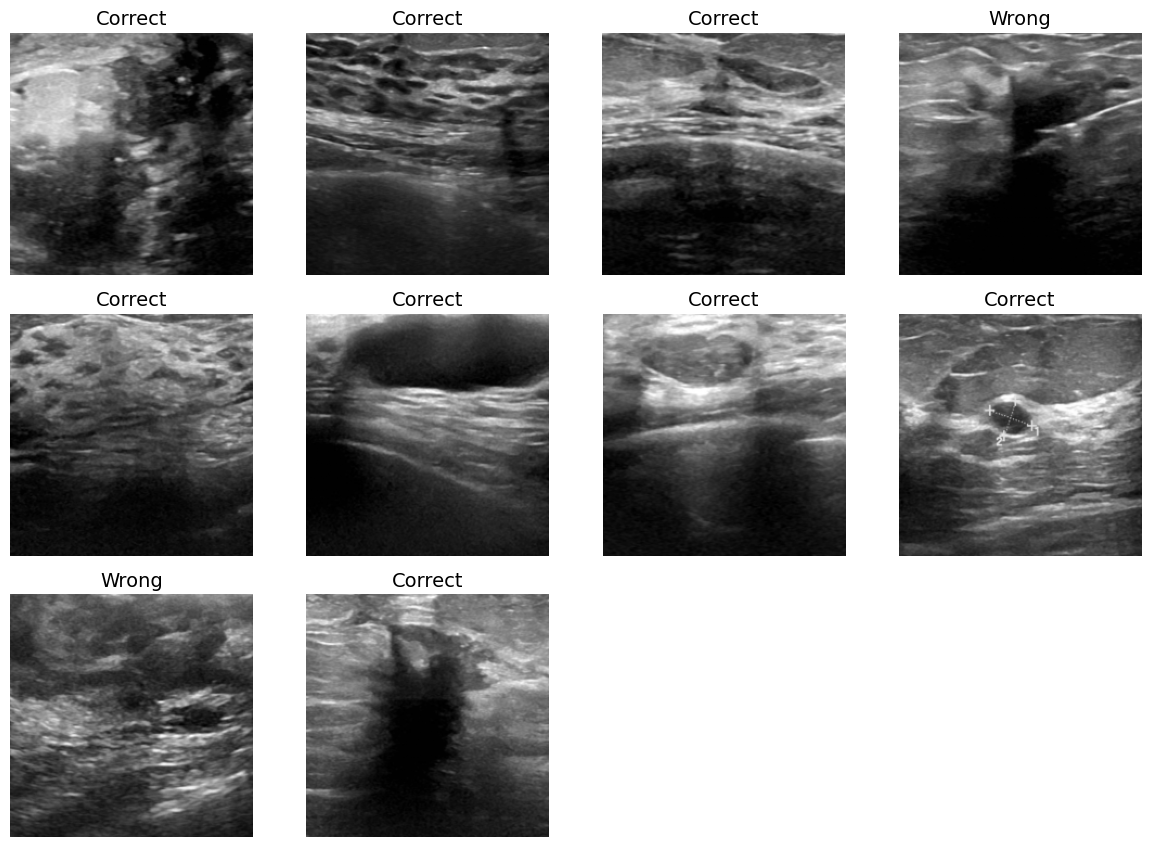

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import torch

max_images = min(10, data_loaders['test'].batch_size)

input_batch, true_batch = next(iter(data_loaders['test']))

input_batch = input_batch.to(device)


gray_images = input_batch.cpu().numpy().mean(axis=1)

trained_model.eval()

with torch.no_grad():

    output_values = trained_model(input_batch)

    _, predicted_batch = torch.max(output_values, 1)


plt.figure(figsize=(12,17))

image_index = 0

while image_index < max_images:

    axis = plt.subplot(6,4,image_index+1)

    axis.axis("off")

    if predicted_batch[image_index] == true_batch[image_index]:
        prediction_status = "Correct"
    else:
        prediction_status = "Wrong"

    axis.set_title(
        f"{prediction_status}",
        fontsize=14
    )

    plt.imshow(gray_images[image_index], cmap="gray")

    image_index += 1


plt.tight_layout()
plt.show()

 The images were divided into three categories which included benign and malignant and normal images for use in training and validation and testing purposes. The classifier used transfer learning with ResNet-101 convolutional neural network which developers implemented using PyTorch. The training dataset contained 306 benign 147 malignant and 93 normal images and the model was trained for 15 epochs during which the training loss decreased from about 54.56 to 15.79 which showed effective learning. The final assessment produced an overall accuracy of about 78.6% which included precision of 78.5% recall of 78.6% and F1-score of 78.3%. The model showed its strongest performance when detecting benign cases which had an F1 score of approximately 0.83 and then performed well on normal cases which had an F1 score of approximately 0.79 but it showed lower performance on malignant cases which had an F1 score of approximately 0.69 because of the decreasing number of samples and the increasing difficulty of tumor patterns.